In [21]:
#> imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#> file imports
import astropy.io.fits as fits
from astropy.table import Table

#> module imports
sys.path.insert(1, '../../../opus/')
import plot
import lensing
import modules.geometry as geometry

### ***Reading All Quad Data***
---

In [22]:
#> image positions file
file = '2026GraL_quads.csv'
pos = pd.read_csv(file)
pos

,TimeDelay,Name,Comp,RAJ2000,DEJ2000,Type,MaxSep,rpos,BibCode,RApdeg,...,e_RACodeg,DECodeg,e_DECodeg,GaiaDR3,AllWISE,recno,ra,dec,dRA,dDEC
0,*,2MASSJ11344050-2103230,A,173.669102,-21.056434,Quad,3.682,Gaia_DR3,2018MNRAS.476..927L,173.669101,...,NaN,NaN,NaN,3541826024524572544,NaN,568,173.669102,-21.056434,0.752181,-0.779
1,*,2MASSJ11344050-2103230,B,173.669319,-21.055947,Quad,3.682,Gaia_DR3,2018MNRAS.476..927L,173.669319,...,NaN,NaN,NaN,3541826024526317568,NaN,569,173.669319,-21.055947,1.481036,0.976
2,*,2MASSJ11344050-2103230,C,173.668522,-21.056649,Quad,3.682,Gaia_DR3,2018MNRAS.476..927L,173.668521,...,NaN,NaN,NaN,3541826024526317312,NaN,565,173.668522,-21.056649,-1.195462,-1.552
3,*,2MASSJ11344050-2103230,D,173.668731,-21.056055,Quad,3.682,Gaia_DR3,2018MNRAS.476..927L,173.668728,...,NaN,NaN,NaN,3541826024524572288,NaN,566,173.668731,-21.056055,-0.495545,0.587
4,*,2MASSJ11344050-2103230,G,173.668878,-21.056218,Quad,3.682,HST,2018MNRAS.476..927L,173.668878,...,NaN,NaN,NaN,-9223372036854775808,NaN,567,173.668878,-21.056218,0.000000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,*,WISE025942.9-163543,A,44.928792,-16.595361,Quad,1.575,Gaia_DR3,2018RNAAS...2...21S,44.928792,...,NaN,NaN,NaN,5153828508862119040,NaN,153,44.928792,-16.595361,0.693842,-0.301
231,*,WISE025942.9-163543,B,44.928700,-16.595117,Quad,1.575,Gaia_DR3,2018RNAAS...2...21S,44.928699,...,NaN,NaN,NaN,5153828504567283072,NaN,152,44.928700,-16.595117,0.376630,0.576
232,*,WISE025942.9-163543,C,44.928365,-16.595205,Quad,1.575,Gaia_DR3,2018RNAAS...2...21S,44.928363,...,NaN,NaN,NaN,5153828508862118912,NaN,149,44.928365,-16.595205,-0.778177,0.261
233,*,WISE025942.9-163543,D,44.928584,-16.595469,Quad,1.575,HST,2018RNAAS...2...21S,44.928584,...,NaN,NaN,NaN,-9223372036854775808,NaN,150,44.928584,-16.595469,-0.023000,-0.691


### ***Calculating Morphological Arrival Sequence***
---
`mo`: name and morphological arrival order

In [23]:
#> iterating through galaxies, ordering
names, arrival_order, ordered_images = [], [], []
for name, lens in pos.groupby('Name'):

    #> galaxy & sorting based on component
    lens = lens.sort_values('Comp')
    
    #> collecting images and ordering
    try:
        images = lens[['dRA', 'dDEC']].to_numpy(dtype=float)
    except ValueError:
        print(f'> {name} is missing at least one image or galaxy position')
        continue

    #> images & labels (galaxy is last after sorting)
    images = lens[['dRA', 'dDEC']].to_numpy(dtype=float)
    labels = np.array(['A', 'B', 'C', 'D'])

    #> ordering
    ordered_ims = lensing.arrivalOrder(images[:-1], images[-1][0], images[-1][1])
    ordered_images.append(np.array(ordered_ims))

    #> order
    images = images[:-1]
    order = [ labels[ np.all(images == im, axis=1) ][0] for im in ordered_ims ]
    arrival_order.append(''.join(order))
    names.append(name)

#> saving as pandas
mo = pd.DataFrame({'Name': np.array(names), 'mo_order': np.array(arrival_order)})
mo

,Name,mo_order
0,2MASSJ11344050-2103230,CBAD
1,2MASXJ01471020+4630433,CBAD
2,ATLASJ2344-3056,BDCA
3,B0712+472,DABC
4,B1422+231,CABD
5,B1555+375,CABD
6,B1608+656,BACD
7,COSMOS5921+0638,CABD
8,DESJ0029-3814,CABD
9,DESJ0053-2012,ACBD


### ***Reading Time-Delays***
---
`hdu=2`: time delays (table B1)

In [24]:
#> reading time delays
file = 'gaia_full_table.fit'
table = Table.read(file, hdu=2).to_pandas()

#> bytes --> strings
for key in table.columns[ table.dtypes == object ]:
    table[key] = table[key].str.decode('utf-8').str.strip()

#> float32 --> float64 (so new delay values can be assigned)
table = table.astype({ key: 'float64' for key in table.columns[ table.dtypes == 'float32' ] })

table

,Name,RAJ2000,DEJ2000,BibCode,tAB,e_tAB,tAC,e_tAC,tAD,e_tAD,tBC,e_tBC,tBD,e_tBD,tCD,e_tCD,Ref,recno
0,DESJ0029-3814,7.419252,-38.240599,2025arXiv250402932D,-6.50,3.000,-6.6,2.7,43.1,2.4,-2.0,3.5,46.7,2.9,49.9,2.7,2025Dux,1
1,J0030-1525,7.563728,-15.417792,2025arXiv250402932D,9.30,1.600,-19.3,3.3,NaN,NaN,-28.5,3.5,NaN,NaN,NaN,NaN,2025Dux,2
2,HE0047-1756,12.615965,-17.669410,2020A&A...642A.193M,-10.80,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020Millon_b,3
3,DESJ0053-2012,13.435089,-20.209228,2025arXiv250402932D,-26.70,2.600,-20.2,2.6,-90.2,6.7,6.3,2.0,-63.5,5.9,-70.2,6.1,2025Dux,4
4,Q0142-100,26.319451,-9.754881,2020A&A...640A.105M,-97.70,16.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020Millon,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,J2205-3727,331.434469,-37.450389,2025arXiv250402932D,-1.80,2.500,0.2,4.3,12.3,1.8,1.7,4.7,14.0,2.7,11.9,4.4,2025Dux,69
69,HS2209+1914,332.876362,19.486972,2023ApJ...950...37M,-21.96,1.448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023Meyer,70
70,SDSSJ2222+2745,335.535891,27.759839,2015ApJ...813...67D,47.70,6.000,-722.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015Dahle,71
71,J2305+3714,346.482476,37.239088,2026MNRAS.546ag023B,52.20,2.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026Burkhonov,72


### ***Time-Delay Corrections***
---

The 2026 GraL catalogue has errors conerning the image component labelling and time delays of certain lenses. These need to be corrected before using the time delays to compare arrival orders.

- **DESJ0029-3814**: Image labels are switched, time delays are not. (B->D, C->B, D->C)
- **WG0214-2105:** Time delays are switched, image labels are not. (B&C)
- **H1413+1170:** Time delays are switched, image labels are not. (A&D, C&B) There are also more available time delays in Table 4, Group I of [[2017 Akhunov]], which is where the abstract values originate from. 
- **SDSSJ1433+6007:** The original time delays are in the format t_XY = t_Y - t_X, not the standard t_XY = t_X - t_Y. Thus, the time delays should be flipped (i.e., tXY = -tXY). See Table 1 of [[2017 Agnello b]], which Table 10 of [[2023 Queirolo]] appears to copy the formalism from.
- **GraLJ203802-400815**: Image labels are switched, time delays are not. (A&C)
- **J2205-3727**: Image labels are switched, time delays are not. (A->C, C->D, D->A)
- **B1608+656**: The original time delays are likely in the format t_XY = t_Y - t_X, not the standard t_XY = t_X - t_Y. The paper states that image B is predicted to be the first arriving from lens modelling, plus, that would make the most sense with lensing theory. [[2010 Suyu]] uses the time delays and changes back to the standard notation, giving the time delays AB = 31.5, CB = 36.0, and DB = 77.0. They also include errors for these three time delays, whereas the catalogue does not include any uncertainties. The original [[2002 Fassnacht]] paper does not include any uncertainties. Finally, the catalogue gives the time delay AC = 2.50, where it should be AC = CB - AB = 4.5 (not including the sign flip). Additionally, CD = 44.0, where it should be CD = DB - CB = 41.0 (not including the sign flip).

In [25]:
#> recalculates the time delays when changing the arrival order
def recalTD(lens, new_order, old_order='ABCD'):

    #> creating copy
    new_lens = lens.copy()

    #> putting nans in all places
    for X, Y in ['AB', 'AC', 'AD', 'BC', 'BD', 'CD']:
        new_lens[f't{X}{Y}'] = np.nan
        new_lens[f'e_t{X}{Y}'] = np.nan

    #> correcting label and transfering
    for X, Y in ['AB', 'AC', 'AD', 'BC', 'BD', 'CD']:
        
        #> getting time delay
        dt = lens[f't{X}{Y}'].iloc[0]
        e_dt = lens[f'e_t{X}{Y}'].iloc[0]
        if np.isnan(dt): continue

        #> converting labels
        X_prime = new_order[old_order.index(X)]
        Y_prime = new_order[old_order.index(Y)]

        #> correcting order of labels in time delay: A is priority, then B, etc.
        if X_prime > Y_prime: 
            X_prime = new_order[old_order.index(Y)]
            Y_prime = new_order[old_order.index(X)]
            factor = -1
        else: 
            factor = 1

        #> saving
        new_lens[f't{X_prime}{Y_prime}'] = dt * factor
        if np.isnan(e_dt): continue
        new_lens[f'e_t{X_prime}{Y_prime}'] = e_dt

    return new_lens

#> changes the sign of all TDs
def flipTD(lens):

    #> creating copy
    new_lens = lens.copy()

    #> putting nans in all places
    for X, Y in ['AB', 'AC', 'AD', 'BC', 'BD', 'CD']:
        new_lens[f't{X}{Y}'] *= -1 

    return new_lens

#> clears TDs
def clearTD(lens):

    #> creating copy
    new_lens = lens.copy()

    #> putting nans in all places
    for X, Y in ['AB', 'AC', 'AD', 'BC', 'BD', 'CD']:
        new_lens[f't{X}{Y}'] = np.nan
        new_lens[f'e_t{X}{Y}'] = np.nan

    return new_lens

In [26]:
#> copying dataframe
df = table.copy()

#> iterating through quads that need to change
for name, lens in df.groupby('Name'):

    #> DESJ0029 (B->D, C->B, D->C)
    if name == 'DESJ0029-3814':
        new_lens = recalTD(lens, 'ADBC')
        df.loc[df['Name'] == name] = new_lens

    #> WG0214-2105 (B&C))
    if name == 'WG0214-2105':
        new_lens = recalTD(lens, 'ACBD')
        df.loc[df['Name'] == name] = new_lens

    #> H1413+117 (A&D, B&C)
    if name == 'H1413+117':
        new_lens = recalTD(lens, 'DCBA')
        new_lens[['tBC','e_tBC']] = [-1.0, 2.9]
        new_lens[['tBD','e_tBD']] = [28.5, 0.6] 
        new_lens[['tCD','e_tCD']] = [28.9, 1.5] 
        df.loc[df['Name'] == name] = new_lens

    #> SDSSJ1433+6007 (flip all signs)
    if name == 'SDSSJ1433+6007':
        new_lens = flipTD(lens)
        df.loc[df['Name'] == name] = new_lens

    #> GraLJ203802-400815 (A&C)
    if name == 'GraLJ203802-400815':
        new_lens = recalTD(lens, 'CBAD')
        df.loc[df['Name'] == name] = new_lens

    #> J2205-3727 (A->C, C->D, D->A)
    if name == 'J2205-3727':
        new_lens = recalTD(lens, 'CBDA')
        df.loc[df['Name'] == name] = new_lens

    #> B1608+656 (many errors)
    if name == 'B1608+656':
        new_lens = clearTD(lens)
        new_lens[['tAB','e_tAB']] = [31.5, 1.5]
        new_lens[['tBC','e_tBC']] = [-36.0, 1.5] 
        new_lens[['tBD','e_tBD']] = [-77.0, 1.5]
        new_lens[['tAC', 'e_tAC']] = [31.5 - 36.0, 1.5]
        new_lens[['tAD', 'e_tAD']] = [31.5 - 77.0, 1.5]
        new_lens[['tCD', 'e_tCD']] = [36.0 - 77.0, 1.5]
        df.loc[df['Name'] == name] = new_lens

df

,Name,RAJ2000,DEJ2000,BibCode,tAB,e_tAB,tAC,e_tAC,tAD,e_tAD,tBC,e_tBC,tBD,e_tBD,tCD,e_tCD,Ref,recno
0,DESJ0029-3814,7.419252,-38.240599,2025arXiv250402932D,-6.60,2.700,43.1,2.4,-6.5,3.0,49.9,2.7,2.0,3.5,-46.7,2.9,2025Dux,1
1,J0030-1525,7.563728,-15.417792,2025arXiv250402932D,9.30,1.600,-19.3,3.3,NaN,NaN,-28.5,3.5,NaN,NaN,NaN,NaN,2025Dux,2
2,HE0047-1756,12.615965,-17.669410,2020A&A...642A.193M,-10.80,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020Millon_b,3
3,DESJ0053-2012,13.435089,-20.209228,2025arXiv250402932D,-26.70,2.600,-20.2,2.6,-90.2,6.7,6.3,2.0,-63.5,5.9,-70.2,6.1,2025Dux,4
4,Q0142-100,26.319451,-9.754881,2020A&A...640A.105M,-97.70,16.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020Millon,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,J2205-3727,331.434469,-37.450389,2025arXiv250402932D,-14.00,2.700,-12.3,1.8,-11.9,4.4,1.8,2.5,1.7,4.7,0.2,4.3,2025Dux,69
69,HS2209+1914,332.876362,19.486972,2023ApJ...950...37M,-21.96,1.448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023Meyer,70
70,SDSSJ2222+2745,335.535891,27.759839,2015ApJ...813...67D,47.70,6.000,-722.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015Dahle,71
71,J2305+3714,346.482476,37.239088,2026MNRAS.546ag023B,52.20,2.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026Burkhonov,72


### ***Time-Delay Arrival Order Function***
---
The function takes as input a pd.DataFrame() row that contains all of the time delays relating to the lens, where $t_{XY} = t_X - t_Y$ in days. To calculate the arrival order from time-delays, there needs to be at least three measured time delays. *However*, every image must appear in at least one delay. In other words, all four images are accounted for. The function works by creating a matrix of linear equations to solve. If the rank of the matrix is below three (i.e., less than three linearly independent equations), there are not enough time delays to calculate an order and `None` is returned. If there are enough, then the set of linear equations is solved by setting $t_A=0$: an exact solution when there are exactly three delays, and the best fit when there are more. It returns the image labels sorted from first to last arrival.

In [27]:
#> arrival order from usable time delays (t_XY = t_X - t_Y)
def TDOrder(lens):

    #> getting time delay pairs, t_X - t_Y (t_A = 0)
    M, d = [], []
    for X, Y in ['AB', 'AC', 'AD', 'BC', 'BD', 'CD']:

        #> getting time delay
        dt = lens[f't{X}{Y}'].iloc[0]
        if np.isnan(dt): continue

        #> setting matrix coefficents
        row = np.zeros(4)
        row['ABCD'.index(X)] = 1  # t_X
        row['ABCD'.index(Y)] = -1 # -t_Y

        #> appending (removing A)
        M.append(row[1:]); d.append(dt)

    #> delays must connect all four images
    if np.linalg.matrix_rank(np.reshape(M, (-1,3))) < 3: return None

    #> arrival times relative to A, solves the linear problem
    t = np.hstack([0.0, np.linalg.lstsq(M, d, rcond=None)[0]])

    #> joining and sorting
    order = ''.join(np.array(list('ABCD'))[np.argsort(t)])
    return order

### ***Calculating the Time-Delay Arrival Order***
---
Removes lenses that contain multiple galaxy components in image positions (i.e., G1 and G2)

In [28]:
#> lenses with more than one galaxy component (GraL table A1)
comp  = Table.read('gaia_full_table.fit', hdu=1).to_pandas()
names = comp['Name'].str.decode('utf-8').str.strip()
isgal = comp['Comp'].str.decode('utf-8').str.strip().str.startswith('G')
multi = set(names[isgal][names[isgal].duplicated()])

#> time-delay orders
td_names, td_order = [], []
for name in df['Name']:

    #> removing galaxies
    if name in multi: continue

    #> ordering
    order = TDOrder(df[ df['Name'] == name ])
    if order is None: continue
    td_names.append(name); td_order.append(order)

#> creating pandas
td = pd.DataFrame({'Name': td_names, 'td_order': td_order})
cols = ['Name', 'tAB', 'e_tAB', 'tAC', 'e_tAC', 'tAD', 'e_tAD', 'tBC', 'e_tBC', 'tBD', 'e_tBD', 'tCD', 'e_tCD','Ref', 'BibCode']

#> merging
merge = pd.merge(td, mo, on='Name')
merge['match'] = merge['td_order'] == merge['mo_order']
merge = pd.merge(merge, df[cols], on='Name')
print(f'> There are {merge['match'].sum()} / {len(merge)} matches!')
merge

> There are 9 / 19 matches!


,Name,td_order,mo_order,match,tAB,e_tAB,tAC,e_tAC,tAD,e_tAD,tBC,e_tBC,tBD,e_tBD,tCD,e_tCD,Ref,BibCode
0,DESJ0029-3814,CADB,CABD,False,-6.60,2.7,43.10,2.4,-6.50,3.0,49.900000,2.7,2.0,3.5,-46.7,2.9,2025Dux,2025arXiv250402932D
1,DESJ0053-2012,ACBD,ACBD,True,-26.70,2.6,-20.20,2.6,-90.20,6.7,6.300000,2.0,-63.5,5.9,-70.2,6.1,2025Dux,2025arXiv250402932D
2,WG0214-2105,CADB,CADB,True,-5.00,0.6,10.70,0.7,-2.90,1.4,15.700000,0.7,2.1,1.4,-13.6,1.3,2025Dux,2025arXiv250402932D
3,WISE025942.9-163543,CABD,CADB,False,-9.00,1.7,8.30,1.4,-17.50,3.4,17.000000,1.5,-8.5,3.4,-25.3,3.4,2025Dux,2025arXiv250402932D
4,J0420-4037,CBAD,CBDA,False,1.70,2.4,7.90,2.6,-7.20,5.1,6.200000,2.3,-8.9,4.9,-14.9,4.9,2025Dux,2025arXiv250402932D
5,HE0435-1223,ACBD,ACBD,True,-9.00,0.8,-0.80,0.8,-13.80,0.8,7.800000,0.8,-6.5,0.7,-14.3,0.8,2020Millon,2020A&A...640A.105M
6,GraLJ065904.1+162909,CADB,CADB,True,-16.10,2.2,262.20,11.1,-14.20,12.8,277.000000,11.4,1.1,13.7,-277.7,14.0,2025Dux,2025arXiv250402932D
7,RXJ0911+0551,DBCA,DBAC,False,10.70,1.7,5.60,1.8,160.00,8.9,-4.800000,1.1,150.0,8.9,154.0,8.8,2025Dux,2025arXiv250402932D
8,SDSS0924+0219,BADC,BADC,True,3.70,0.9,-17.50,3.4,-1.60,3.6,-21.500000,3.5,-5.2,3.7,14.7,5.0,2025Dux,2025arXiv250402932D
9,RXJ1131-1231,BACD,CBAD,False,1.60,0.7,-1.00,1.2,-92.50,1.9,-2.000000,1.4,-93.7,2.0,-91.8,2.3,2020Millon,2020A&A...640A.105M


### ***Checking Individual Lenses***
---
`idx`: the index of the quad in the `merge` dataframe

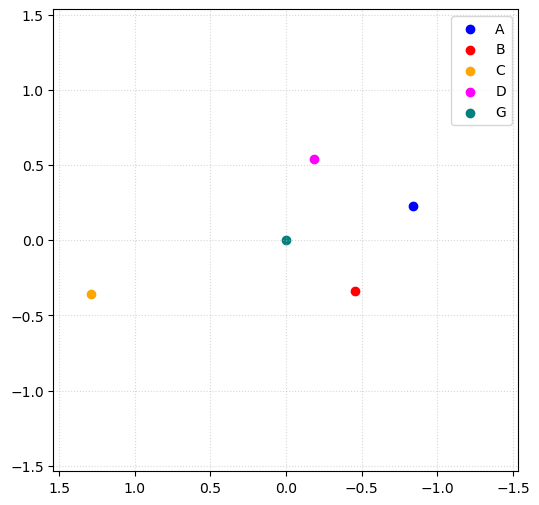

In [29]:
#> lens index
idx = 0

#> parsing data
lens = pos[ pos['Name'] == merge.loc[idx]['Name'] ]
images = lens[['dRA', 'dDEC']].to_numpy(dtype=float)
comp = lens['Comp'].to_numpy()

#> initializing plot
fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.grid(ls=':', alpha=0.5)

#> plotting
for i in range(len(images)):
    ax.scatter(images[i,0], images[i,1], label=comp[i])


akhunov = np.array([[0,0],
           [0.744,0.168],
           [-0.492,0.713],
           [0.354,1.040],
           [-0.142,0.561]])
akhunov -= akhunov[-1]

c = ['b', 'r', 'orange', 'm']
#for i in range(4):
    #ax.scatter(akhunov[i,0], akhunov[i,1], marker='+', c=c[i])

#> adjusting
plot.toBox(ax)
plot.ticks(ax)
ax.invert_xaxis()

plt.legend()
plt.show()

### ***Comparison to Accepted Quads***
---
The GraL list of quads contains lenses that are not 'accepted' in the final catalogue of quads due to various cuts. The next block selects the galaxies that are 'accepted' to compare with.

In [30]:
#> list of 'accepted' quad names
file = '../quad_names.csv'
accepted_names = pd.read_csv(file)
accepted = accepted_names['Name']

#> orders of accepted lenses
accepted_orders = merge[ merge['Name'].isin(accepted) ].reset_index(drop=True)

#> getting lens that weren't accepted
not_accepted_orders = merge[ ~merge['Name'].isin(accepted) ]['Name'].to_dict()

print(f'> The following lenses were not accepted: {not_accepted_orders}')
accepted_orders

> The following lenses were not accepted: {15: 'B1608+656'}


,Name,td_order,mo_order,match,tAB,e_tAB,tAC,e_tAC,tAD,e_tAD,tBC,e_tBC,tBD,e_tBD,tCD,e_tCD,Ref,BibCode
0,DESJ0029-3814,CADB,CABD,False,-6.60,2.7,43.10,2.4,-6.50,3.0,49.900000,2.7,2.0,3.5,-46.7,2.9,2025Dux,2025arXiv250402932D
1,DESJ0053-2012,ACBD,ACBD,True,-26.70,2.6,-20.20,2.6,-90.20,6.7,6.300000,2.0,-63.5,5.9,-70.2,6.1,2025Dux,2025arXiv250402932D
2,WG0214-2105,CADB,CADB,True,-5.00,0.6,10.70,0.7,-2.90,1.4,15.700000,0.7,2.1,1.4,-13.6,1.3,2025Dux,2025arXiv250402932D
3,WISE025942.9-163543,CABD,CADB,False,-9.00,1.7,8.30,1.4,-17.50,3.4,17.000000,1.5,-8.5,3.4,-25.3,3.4,2025Dux,2025arXiv250402932D
4,J0420-4037,CBAD,CBDA,False,1.70,2.4,7.90,2.6,-7.20,5.1,6.200000,2.3,-8.9,4.9,-14.9,4.9,2025Dux,2025arXiv250402932D
5,HE0435-1223,ACBD,ACBD,True,-9.00,0.8,-0.80,0.8,-13.80,0.8,7.800000,0.8,-6.5,0.7,-14.3,0.8,2020Millon,2020A&A...640A.105M
6,GraLJ065904.1+162909,CADB,CADB,True,-16.10,2.2,262.20,11.1,-14.20,12.8,277.000000,11.4,1.1,13.7,-277.7,14.0,2025Dux,2025arXiv250402932D
7,RXJ0911+0551,DBCA,DBAC,False,10.70,1.7,5.60,1.8,160.00,8.9,-4.800000,1.1,150.0,8.9,154.0,8.8,2025Dux,2025arXiv250402932D
8,SDSS0924+0219,BADC,BADC,True,3.70,0.9,-17.50,3.4,-1.60,3.6,-21.500000,3.5,-5.2,3.7,14.7,5.0,2025Dux,2025arXiv250402932D
9,RXJ1131-1231,BACD,CBAD,False,1.60,0.7,-1.00,1.2,-92.50,1.9,-2.000000,1.4,-93.7,2.0,-91.8,2.3,2020Millon,2020A&A...640A.105M


In [31]:
#> saving
accepted_orders.to_csv('accepted_quads_orders.csv', index=False)